Alumna: Castillo Dorantes Sandra Geraldine

# Ejercicio Integrador - Modulo 2 - Tema 2
##

In [1]:
# Librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from scipy.stats import boxcox, yeojohnson
import warnings
warnings.filterwarnings('ignore')

# Leer parquet
RUTA = "C:/Users/HP/diplomado-ml-seguros/Modulo_2"
#"C:\Users\HP\diplomado-ml-seguros\Modulo_2"

datos = pd.read_parquet(RUTA + "/cartera_q1_2026_final.parquet")
ac = datos[datos['ramo'] == 'Accidentes Personales']
gm = datos[datos['ramo'] == 'GMM']

1.	Calcular estadísticas descriptivas (número de pólizas, prima total, prima promedio, número de siniestros, siniestro promedio, etc.)

In [2]:
print("ESTADISTICAS DESCRIPTIVAS")
print("=" * 40)
print(f"Numero de polizas: {datos['id_poliza'].count()} polizas")
print(f"Prima total: ${datos['prima_total'].sum():,.2f}")
print(f"Prima promedio: ${datos['prima_total'].mean():,.2f}")
print(f"Prima neta total: ${datos['prima_neta'].sum():,.2f}")
print(f"Prima neta promedio: ${datos['prima_neta'].mean():,.2f}")
print(f"Total de siniestros: {datos['n_siniestros'].sum():,}")
print(f"Promedio de siniestros: {datos['n_siniestros'].mean():,.2f}")
print(f"Prima mensual promedio: ${datos['prima_mensual'].mean():,.2f}")
print(f"Numero de mujeres: {len(datos[datos['sexo'] == 'F']):,} mujeres")
print(f"Numero de hombres: {len(datos[datos['sexo'] == 'M']):,} hombres")

ESTADISTICAS DESCRIPTIVAS
Numero de polizas: 50000 polizas
Prima total: $1,464,158,630.80
Prima promedio: $29,283.17
Prima neta total: $1,215,667,338.00
Prima neta promedio: $24,313.35
Total de siniestros: 18,000.0
Promedio de siniestros: 0.36
Prima mensual promedio: $2,440.26
Numero de mujeres: 25,051 mujeres
Numero de hombres: 24,949 hombres


2.	Obtener los histogramas de las variables: sexo, edad, año de inicio de vigencia, plan, primas y siniestros. ¿Qué observas?

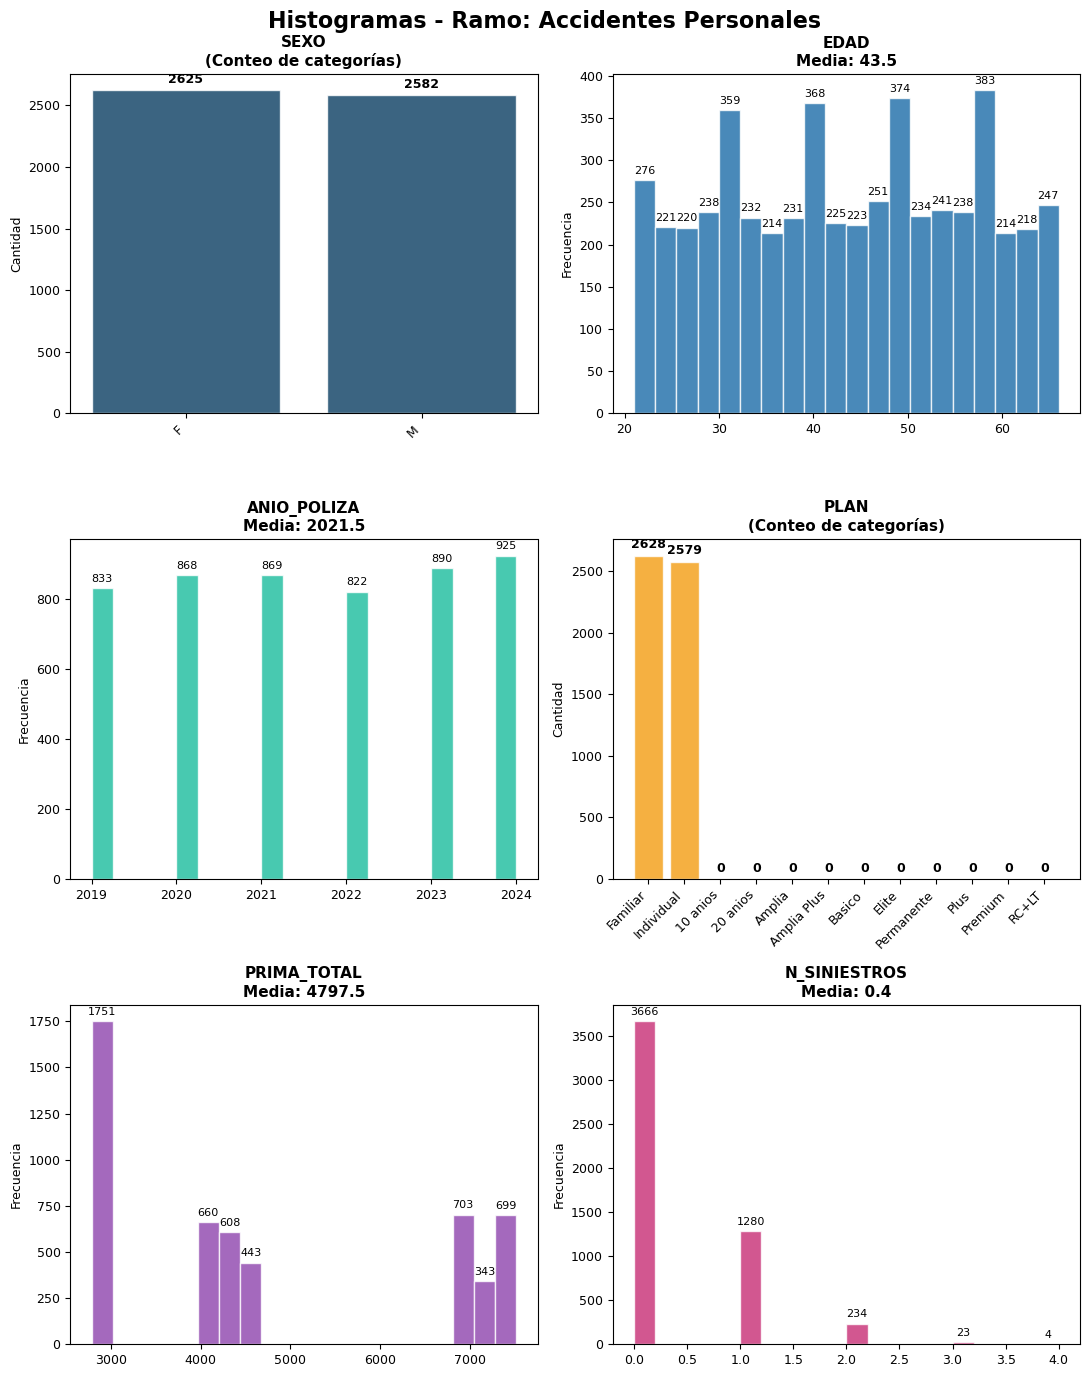

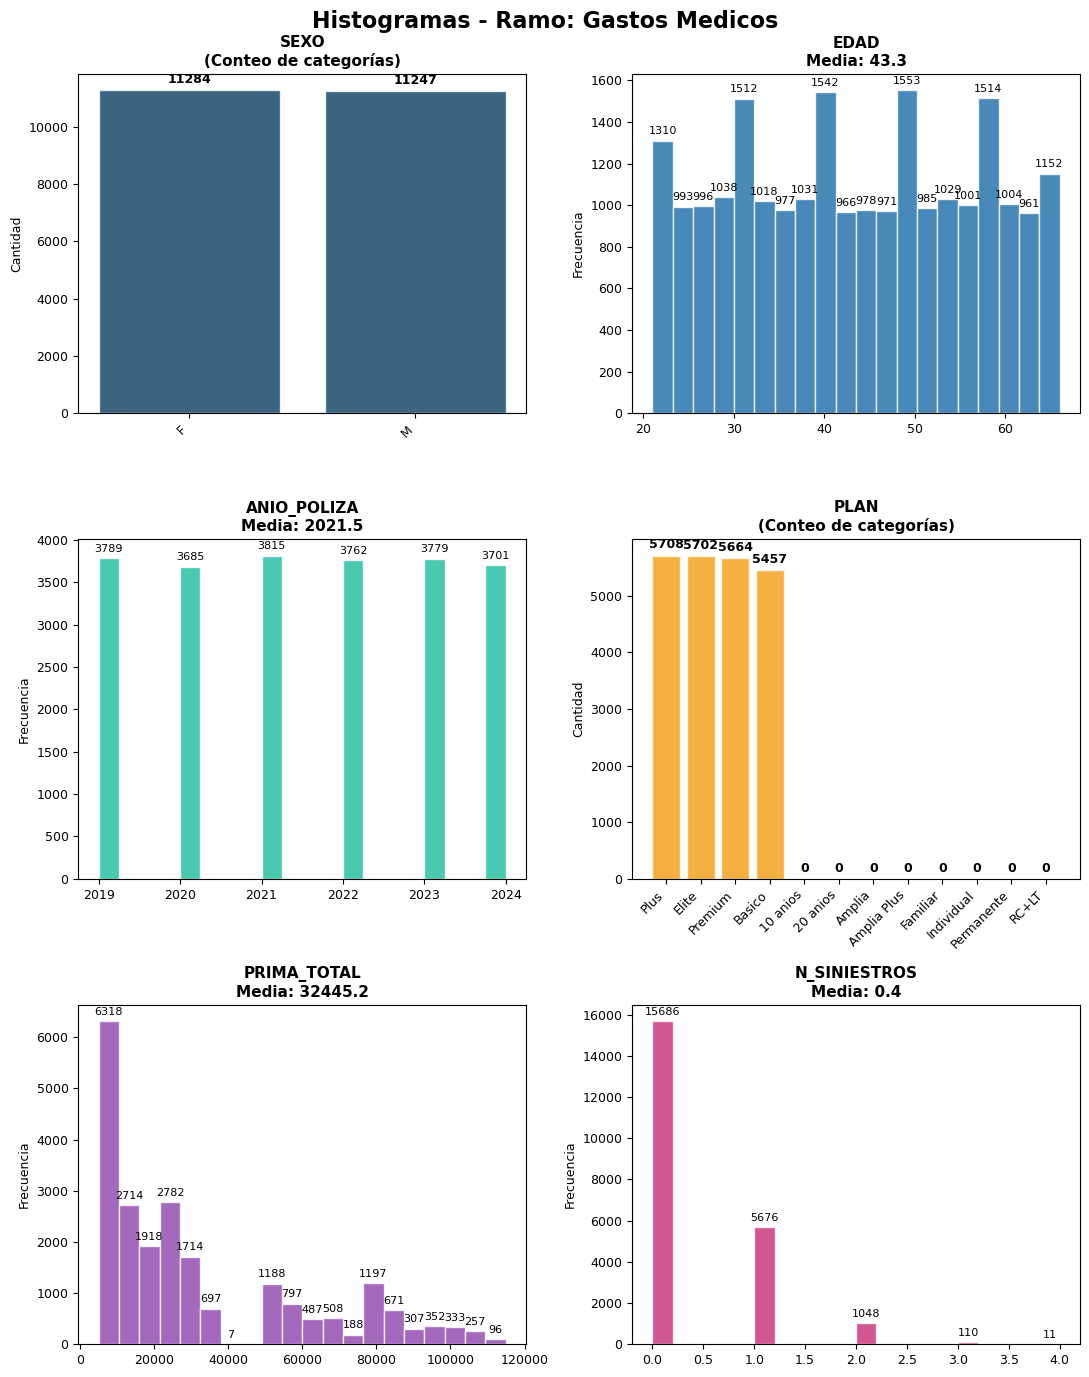

In [3]:
def histogramas(datos, titulo):
    fig, axes = plt.subplots(3, 2, figsize=(11, 14))

    cols = ['sexo', 'edad', 'anio_poliza', 'plan', 'prima_total', 'n_siniestros']
    colors = ['#0A3D62', '#1B6CA8', '#1ABC9C', '#F39C12', '#8E44AD', "#C72D75"]

    axes_flat = axes.flatten()

    for i, (col, ax, c) in enumerate(zip(cols, axes_flat, colors)):

        # Si la columna es categoría (sexo o plan) usamos grafico de barras
        if col in ['sexo', 'plan']:
            conteo = datos[col].value_counts()
            barras = ax.bar(conteo.index, conteo.values, color=c, alpha=0.8, edgecolor='white')
            
            ax.bar_label(barras, padding=3, fontsize=9, fontweight='bold')
            
            ax.set_title(f'{col.upper()}\n(Conteo de categorías)', fontsize=11, fontweight='bold')
            ax.set_ylabel('Cantidad', fontsize=9)
            
            ax.set_xticklabels(conteo.index, rotation=45, ha='right', fontsize=9)
        
        # Si la columna es numérica usamos histograma
        else:
            conteos_hist, bines, parches = ax.hist(datos[col].dropna(), bins=20, color=c, alpha=0.8, edgecolor='white')
            
            ax.bar_label(parches, padding=3, fontsize=8, fmt=lambda x: f'{int(x)}' if x > 0 else '')
            
            media = datos[col].mean()
            ax.set_title(f'{col.upper()}\nMedia: {media:.1f}', fontsize=11, fontweight='bold')
            ax.set_ylabel('Frecuencia', fontsize=9)

        ax.tick_params(axis='both', labelsize=9)

    fig.suptitle(titulo, fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()

histogramas(ac, 'Histogramas - Ramo: Accidentes Personales')
histogramas(gm, 'Histogramas - Ramo: Gastos Medicos')

# COMENTARIOS
# Accidentes personales
# Podemos obcervar que para el sexo la distribución es muy parecida, tanto hombres como mujees 
# tienen una frecuencia similar.
# En cuanto a la edad, hay mas personas con edades iguales a 20, 30, 40, 50 y cerca de los 60. La 
# distribucion es muy similar para todas las demas edades restantes.
# Los años de las polizas de igual forma se ven muy similares en todos los años.
# Los planes, a diferencia de las anteriores, vemos que se concentran los casos donde el plan es 
# familiar o individual.
# En el grafico de primas, vemos que la mayoria de ellas son menores a $3000
# Finalmente, con la grafica de siniestos observamos que la mayoria de las polizas no tienen siniestros.
# Gastos medicos mayores
# Para gastos medicos los histogramas son muy similares, los sexos se distribuyen uniforme, las edades
# tienen mayor numero en las mismas edadas (20, 30, 40, 50, 60), los años parecen bastante uniformes
# tambien, pero en este caso los planes se concentran en Plus, Elite, Premium y basico.
# Finalmente, en las ultimas graficas, de igual forma vemos mucha concentracion en la prima menor a 
# $3,000 y las polizas sin siniestros.

3.	Codifica las variables que consideres necesario. Explica por qué consideraste esas variables y que tipo de codificación aplicaste.

In [4]:
# Veamos las variables categoricas o de texto que se tienen en el dataframe
print("Variables categoricas o de texto")
print("================================")
categoricas = datos.select_dtypes(include=['object', 'category']).dtypes
print(categoricas)
print()

# Veamos cuantos datos unicos tiene cada variable categorica
print("DATOS UNICOS POR COLUMNA")
print("--------------------------")
print(f"{'Columna':<20}   Datos unicos")
for i in categoricas.index.to_list():
    print(f"{i:<21}  {len(datos[i].unique()):<12}")
print()

# Algunas varibles como id_poliza, num_poliza, nombre, apellido_materno/paterno, rfc, etc; 
# son identificadores e informacion del cliente, por lo que no conviene codificarlas. Ademas,
# muchas de ellas tienen muchos valores diferentes y codificarlas resultaría muy complicado e
# innecesario

# VARIABLES QUE PODEMOS CODIFICAR
# Puede resultar útil codificar variables como sexo, estado_civil, ocupacion, plan, status_poliza, 
# motivo_baja, canal_venta, marca_vehiculo, tipo_vehiculo, forma_pago, estado, municipio, region, 
# tipo_agente, tipo_principal, nivel_riesgo, segmento_prima_fijo, cuartil_prima

# Algunas variables solo aplican para el ramo de autos, esas no las codificaremos, principalmente
# porque estamos trabajando con gastos medicos y accidentes personales. De igual forma, no tomaremos
# las columnas que son por ramo como cod_ramo o ramo_desde_codigo, ya que es redundante con la columna
# de ramo.

# ONE HOT ENCODING
# Lo usaremos para variables con pocos valores y que no tienen un orden como sexo, estado_civil, 
# status_poliza, motivo_baja, canal_venta, forma_pago, tipo_agente y tipo_principal

# LABEL ENCODING
# Lo usaremos para variables que sí tienen un orden logico como nivel_riesgo, segmento_prima_fijo, 
# y cuartil_prima

# LABEL ENCODING
# Lo usaremos para variables con muchos elementos distintos como plan, estado, municipio, region
# y ocupacion

# ====================================================
# ================= ONE HOT ENCODING =================
# ====================================================

def ohe(datos, ohe_list):
    print("\n ANTES:")
    print("-"*60)
    print(datos[ohe_list].head(6).to_string())

    list_dummies = []
    list_referencias = []
    columnas_nuevas = 0
    for i in ohe_list:
        dummies = pd.get_dummies(datos[i], prefix=i, drop_first=True)
        if datos[i].dtype == 'category':
            referencia = datos[i].cat.categories[0]
        else:
            referencia = sorted(datos[i].dropna().unique())[0]
        list_referencias.append(referencia)
        list_dummies.append(dummies)
        columnas_nuevas += dummies.shape[1]
    
    print("-"*60)
    print(f"\nDESPUÉS: \nCategorias de referencia:")
    for a,b in zip(ohe_list, list_referencias):
        print(f"  • Columna: {a} - Referencia: {b}")
    total_dummies = pd.concat(list_dummies, axis = 1)
    print("-"*60)
    print(total_dummies.head(8).astype(int).to_string())
    print("-"*60)

    # Agregar al dataframe
    df_ohe = pd.concat([datos] + list_dummies, axis=1)
    print(f"\n✅ Se crearon {columnas_nuevas} columnas nuevas")
    print("Columnas de referencia eliminadas\n")

    return df_ohe

# Columnas en las que usaremos one hot encoding
cols_ohe = ['sexo', 'estado_civil', 'status_poliza','motivo_baja', 
             'canal_venta', 'forma_pago', 'tipo_agente', 'tipo_principal']

print("======================================================")
print("=== ONE HOT ENCODING - RAMO: ACCIDENTES PERSONALES ===")
print("======================================================")
ac_ohe = ohe(ac, cols_ohe)

print("=====================================================")
print("== ONE HOT ENCODING - RAMO: GASTOS MEDICOS MAYORES ==")
print("=====================================================")
gm_ohe = ohe(gm, cols_ohe)

# ====================================================
# ================== LABEL ENCODING ==================
# ====================================================

def label_encoding(df, cols_le, ordenes_le):
    datos = df.copy()
    cols_originales = datos.columns
    for col, orden in zip(cols_le, ordenes_le):
        print(f"\n------------ COLUMNA: {col}")
        datos[f"{col}_encoded"] = datos[col].map(orden)
        print("Variable ordinal con order correcto:")
        print(datos[[col, f"{col}_encoded"]].drop_duplicates().sort_values(f"{col}_encoded"))

    cols_nuevas =  set(datos.columns) - set(cols_originales)
    print(f"Se crearon {len(cols_nuevas)} columnas nuevas\n")
    for c in cols_nuevas:
        print(f"  • {c}")

    return datos

# Columnas en las que usaremos label bencoding
cols_le = ['nivel_riesgo', 'segmento_prima_fijo', 'cuartil_prima']

ordenes_le = [{'BAJO': 0, 'MEDIO': 1, 'ALTO': 2}, 
              {'Basica': 0, 'Media' : 1,  'Alta': 2, 'Premium':3}, 
              {'Q1':0, 'Q2':1, 'Q3':2, 'Q4':3}]

print("====================================================")
print("=== LABEL ENCODING - RAMO: ACCIDENTES PERSONALES ===")
print("====================================================")
ac_le = label_encoding(ac, cols_le, ordenes_le)

print()
print("=====================================================")
print("=== LABEL ENCODING - RAMO: GASTOS MEDICOS MAYORES ===")
print("=====================================================")
gm_le = label_encoding(gm, cols_le, ordenes_le)

# ===================================================
# ================= TARGET ENCODING =================
# ===================================================

def target(df, target_columns):
    datos = df.copy()
    datos['tiene_siniestro'] = (datos['n_siniestros'] > 0).astype(int)
    tasa_global = datos['tiene_siniestro'].mean()
    col_originales = datos.columns
    for col in target_columns:
        target_encoding = datos.groupby(col)['tiene_siniestro'].agg(['mean', 'count']).rename(
            columns = {'mean':'tasa_siniestralidad', 'count': 'num_polizas'})
        print(f"\n---------- COLUMNA: {col} ------------")
        print(target_encoding.round(4))
        mapa = target_encoding['tasa_siniestralidad'].to_dict()
        datos[f"{col}_target_encoded"] = datos[col].map(mapa).astype(float)
        datos[f"{col}_target_encoded"] = datos[f"{col}_target_encoded"].fillna(tasa_global)
        print(f"\nColumna codificada con tasa de siniestralidad")
        print(datos[[col, f"{col}_target_encoded"]].drop_duplicates().sort_values(f"{col}_target_encoded",
                                                                                ascending=False)) 

    columnas_nuevas = set(datos.columns)-set(col_originales)
    print(f"\nSe crearon {len(columnas_nuevas)} columnas nuevas:")
    for c in columnas_nuevas:
        print(f"  • {c}")

    return datos

target_columns = ['plan', 'estado', 'municipio', 'region', 'ocupacion']

print()
print("=====================================================")
print("=== TARGET ENCODING - RAMO: ACCIDENTES PERSONALES ===")
print("=====================================================")
ac_target = target(ac, target_columns)

print()
print("======================================================")
print("=== TARGET ENCODING - RAMO: GASTOS MEDICOS MAYORES ===")
print("======================================================")
gm_target = target(gm, target_columns)

Variables categoricas o de texto
id_poliza                object
num_poliza               object
nombre                 category
apellido_paterno       category
apellido_materno       category
rfc                      object
sexo                   category
estado_civil           category
ocupacion              category
ramo                   category
plan                   category
status_poliza          category
motivo_baja            category
canal_venta            category
marca_vehiculo         category
tipo_vehiculo          category
forma_pago             category
agente_id                object
estado                 category
municipio              category
nombre_agente            object
region                   object
tipo_agente              object
tipo_principal           object
nivel_riesgo           category
segmento_prima_fijo    category
cuartil_prima          category
cod_ramo                 object
ramo_desde_codigo        object
dtype: object

DATOS UNICOS POR COLUMNA

4.	Aplicar los 3 tipos de escalamiento a primas y siniestros. Obtén sus estadísticas y compáralas con las originales. ¿Qué concluyes?

In [5]:
# ===========================================
# ================= MIN MAX =================
# ===========================================

def minmax(datos, columns):
    scaler_minmax = MinMaxScaler()
    print("--------- ESTADISTICAS ANTES DE MIN-MAX: ---------")
    print(datos[columns].describe().round(4).to_string())
    df_minmax = pd.DataFrame(
        scaler_minmax.fit_transform(datos[columns]),
        columns=[f'{c}_mm' for c in columns],
        index=datos.index
    )
    print("\n--------- ESTADISTICAS DESPUES DE MIN-MAX: ---------")
    print(f"{df_minmax.describe().round(4).to_string()}")
    return df_minmax

cols_minmax = ['prima_neta', 'prima_total', 'monto_reclamado', 'monto_pagado', 'prima_mensual']

print()
print("=============================================")
print("=== MIN-MAX - RAMO: ACCIDENTES PERSONALES ===")
print("=============================================")
ac_minmax = minmax(ac, cols_minmax)
print()
print("==============================================")
print("=== MIN-MAX - RAMO: GASTOS MEDICOS MAYORES ===")
print("==============================================")
gm_minmax = minmax(gm, cols_minmax)

# ===========================================
# ================= Z SCORE =================
# ===========================================

def z_score(datos, columns):
    scaler_zscore = StandardScaler()
    print("\n--------- ESTADISTICAS ANTES DE Z-SCORE: ---------")
    print(datos[columns].describe().round(4).to_string())
    df_zscore = pd.DataFrame(
        scaler_zscore.fit_transform(datos[columns]),
        columns=columns,
        index=datos.index
    )

    print("\n----- ESTADISTICAS DESPUÉS DE Z-SCORE: -----")
    print(df_zscore.describe().round(4).to_string())
    print("\nTodas las variables tienen media ≈ 0 y desv. est. ≈ 1")

    return df_zscore

cols_z_score = ['monto_pagado', 'prima_total']
print()
print("=============================================")
print("=== Z-SCORE - RAMO: ACCIDENTES PERSONALES ===")
print("=============================================")
ac_zs = z_score(ac, cols_z_score)
print()
print("==============================================")
print("=== Z-SCORE - RAMO: GASTOS MEDICOS MAYORES ===")
print("==============================================")
gm_zs = z_score(gm, cols_z_score)


from sklearn.preprocessing import RobustScaler

def r_scaler(datos, columns):
    # Hacemos esto debido a que la columna puede tener cuantiles igual a cero
    scaler_rscaler = RobustScaler(quantile_range=(10.0, 90.0))
    
    print("\n------ ESTADISTICAS ANTES DE ROBUST SCALER: ------")
    print(datos[columns].describe().round(4).to_string())    
    df_rscaler = pd.DataFrame(
        scaler_rscaler.fit_transform(datos[columns]),
        columns=columns,
        index=datos.index
    )

    print("\n----- ESTADISTICAS DESPUES DE ROBUST SCALER: -----")
    print(df_rscaler.describe().round(4).to_string())
    print("\n✅ Transformación exitosa: Todas las variables tienen mediana = 0 e IQR = 1")
    
    return df_rscaler


cols_r_scaler = ['monto_pagado', 'prima_total']

print()
print("===================================================")
print("=== ROBUST SCALER - RAMO: ACCIDENTES PERSONALES ===")
print("===================================================")
ac_rscaler = r_scaler(ac, cols_r_scaler)
print()
print("====================================================")
print("=== ROBUST SCALER - RAMO: GASTOS MEDICOS MAYORES ===")
print("====================================================")
gm_rscaler = r_scaler(gm, cols_r_scaler)

# COMENTARIOS
# Observamos que el metodo min-max para los montos reclamados y pagados hace que los datos
# se concentren en valores muy cercanos a cero. Para las primas el metodo funciono de forma 
# equilibrada. La distribucion se concentra en el cero, pero tambien se distribuye en los demas
# cuartiles.
# El escalamiento con Z-Score muestra una distribución muy simetrica para las primas, pero muy
# sesgada a la derecha para los montos. Ademas, el valor máximo se disparo a montos muy altos
# en ambos ramos. Para las primas sucede algo similar, pero los montos maximos permanecieron estables.
# El escalamiento con Robust Scaler muestra una distribucion simetrica para las primas, vemos que
# la mediana se situó en cero y los demas montos de prima se distribuyen alrededor. Sin embargo, 
# para los montos pagados, la distribucion nuevamente se mantiene en el cero y se dispara mucho mas
# que con Z-Score a montos grandes.


=== MIN-MAX - RAMO: ACCIDENTES PERSONALES ===
--------- ESTADISTICAS ANTES DE MIN-MAX: ---------
       prima_neta  prima_total  monto_reclamado  monto_pagado  prima_mensual
count   5207.0000    5207.0000     5.207000e+03  5.207000e+03      5207.0000
mean    3995.0067    4797.5185     1.299009e+04  4.284885e+03       399.7932
std     1489.7698    1804.0263     4.059326e+04  2.576129e+04       150.3355
min     2400.0000    2784.0000     0.000000e+00  0.000000e+00       232.0000
25%     2400.0000    3006.7200     0.000000e+00  0.000000e+00       250.5600
50%     3600.0000    4301.2800     0.000000e+00  0.000000e+00       358.4400
75%     6000.0000    6960.0000     8.442940e+03  0.000000e+00       580.0000
max     6000.0000    7516.8000     1.224593e+06  1.067934e+06       626.4000

--------- ESTADISTICAS DESPUES DE MIN-MAX: ---------
       prima_neta_mm  prima_total_mm  monto_reclamado_mm  monto_pagado_mm  prima_mensual_mm
count      5207.0000       5207.0000           5207.0000       

5.	Haz la transformación Box-Cox, logarítmica y Yeo-Johnson al monto del siniestro. Haz un histograma de la serie original y cada una de las transformaciones. Agrega la distribución normal.


======== LOGARITMICA ========

------- Accidentes Personales

✅ La asimetría bajó de 20.52 a 2.43

------ Gastos Medicos Mayores

✅ La asimetría bajó de 10.87 a 2.35

========== BOX COX ==========

------- Accidentes Personales
🎯 Lambda óptimo encontrado: λ = -0.8539

------- Gastos Medicos Mayores
🎯 Lambda óptimo encontrado: λ = -0.8178

========== YEO JOHNSON ==========

---------- Accidentes Personales
📊 Datos de montos de siniestros:
  Rango: $0 a $1,067,934

🎯 Lambda Yeo-Johnson óptimo: λ = -0.8539

---------- Gastos Medicos Mayores
📊 Datos de montos de siniestros:
  Rango: $0 a $698,744

🎯 Lambda Yeo-Johnson óptimo: λ = -0.8178


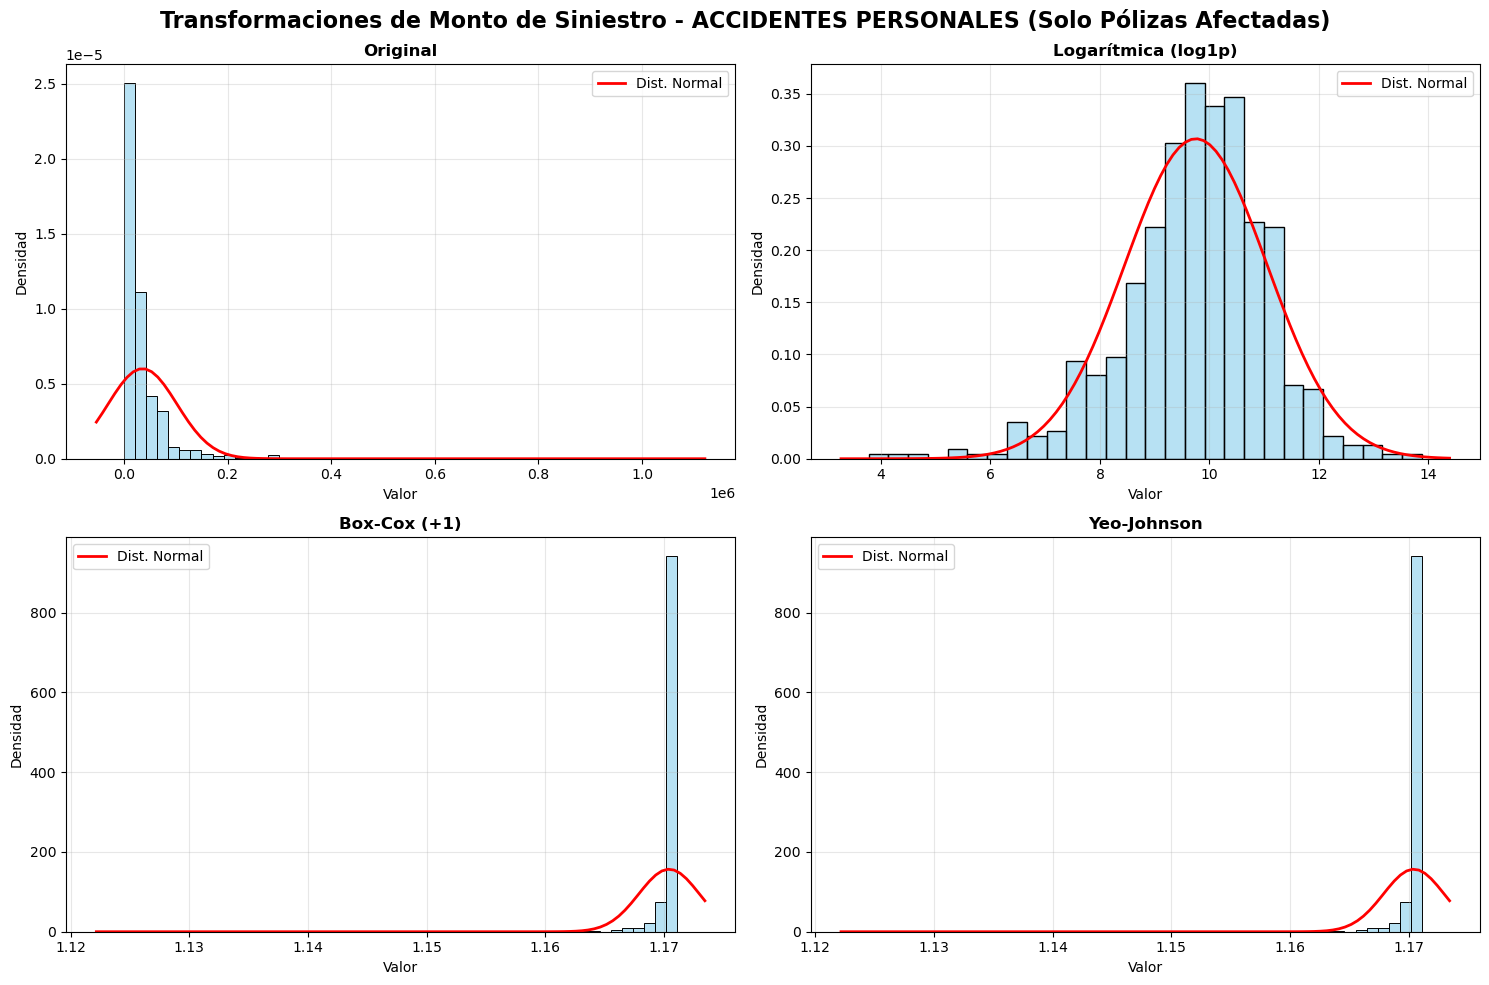

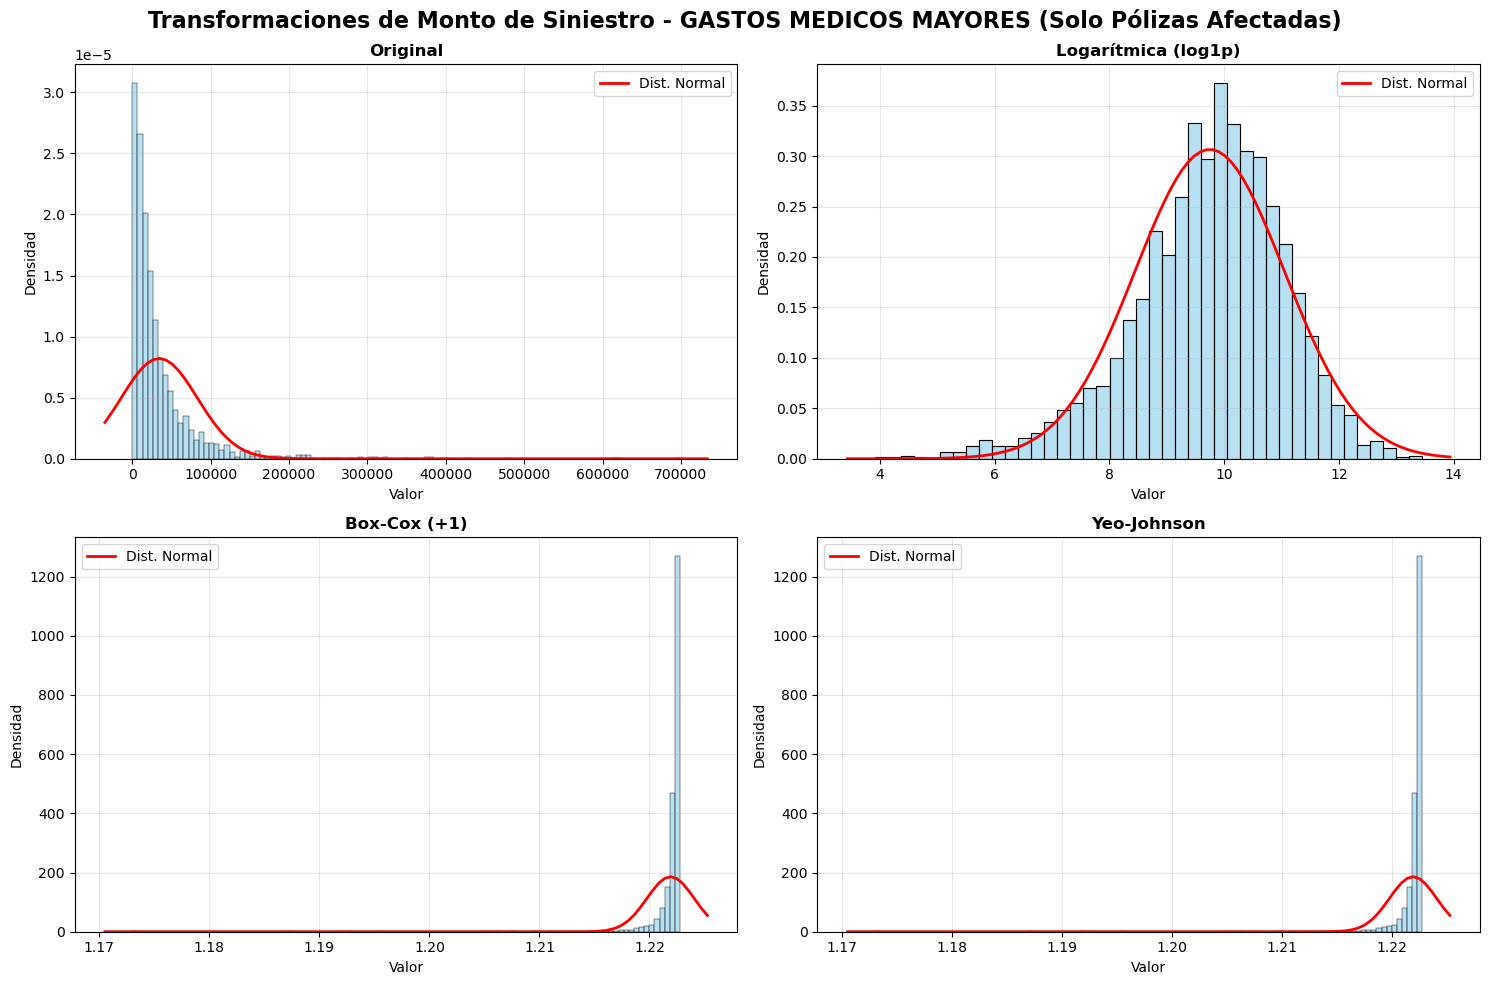

In [6]:
# ===========================================
# =============== LOGARITMICA ===============
# ===========================================

def t_log(df):
    datos = df.copy()
    datos['log_siniestro'] = np.log1p(datos['monto_pagado'])
    print(f"\n✅ La asimetría bajó de {datos['monto_pagado'].skew():.2f} a {datos['log_siniestro'].skew():.2f}")
    return datos

print("\n=============================")
print("======== LOGARITMICA ========")
print("=============================\n")

print("------- Accidentes Personales")
ac_log = t_log(ac)

print("\n------ Gastos Medicos Mayores")
gm_log = t_log(gm)

# =======================================
# =============== BOX COX ===============
# =======================================

def t_boxcox(df):
    y = df['monto_pagado'].values + 1
    y_boxcox, lambda_optimo = boxcox(y)

    print(f"🎯 Lambda óptimo encontrado: λ = {lambda_optimo:.4f}")

    return y_boxcox, lambda_optimo

print("\n=============================")
print("========== BOX COX ==========")
print("=============================\n")

print("------- Accidentes Personales")
y_bc_ac, lambda_bc_ac = t_boxcox(ac)

print("\n------- Gastos Medicos Mayores")
y_bc_gm, lambda_bc_gm = t_boxcox(gm)

# ===========================================
# =============== YEO JOHNSON ===============
# ===========================================

def yeo_johnson(df):
    # Aplicar Yeo-Johnson (funciona con valores negativos)
    y = df['monto_pagado'].values  # Puede ser negativo

    # Yeo-Johnson
    y_yj, lambda_yj = yeojohnson(y)

    print(f"📊 Datos de montos de siniestros:")
    print(f"  Rango: ${y.min():,.0f} a ${y.max():,.0f}")
    print(f"\n🎯 Lambda Yeo-Johnson óptimo: λ = {lambda_yj:.4f}")

    return y_yj, lambda_yj

print("\n=================================")
print("========== YEO JOHNSON ==========")
print("=================================\n")

print("---------- Accidentes Personales")
y_yj_ac, lambda_yj_ac = yeo_johnson(ac)

print("\n---------- Gastos Medicos Mayores")
y_yj_gm, lambda_yj_gm = yeo_johnson(gm)

# import matplotlib.pyplot as plt
# import numpy as np
# import seaborn as sns
from scipy.stats import norm

# ========================================
# =============== GRAFICAS ===============
# ========================================

def graficar_transformaciones(
    monto_original, monto_log, monto_bc, monto_yj, titulo_ramo
):
    # Creamos una figura con 4 subtramas (2 filas y 2 columnas)
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(
        f"Transformaciones de Monto de Siniestro - {titulo_ramo}",
        fontsize=16,
        fontweight="bold",
    )

    # Lista de las 4 series que vamos a graficar y sus títulos
    series = [monto_original, monto_log, monto_bc, monto_yj]
    titulos = ["Original", "Logarítmica (log1p)", "Box-Cox (+1)", "Yeo-Johnson"]

    # Aplanamos la matriz de ejes (2x2) a una lista de 4 elementos para iterar fácil
    axes = axes.flatten()

    for i in range(4):
        ax = axes[i]
        data = series[i]

        # 1. Dibujamos el histograma base (normalizado con stat='density')
        sns.histplot(
            data, kde=False, stat="density", color="skyblue", alpha=0.6, ax=ax
        )
        mu, std = norm.fit(data)  # Calcula la media y desv. estándar de la serie
        xmin, xmax = ax.get_xlim()  # Obtiene los límites del gráfico
        x = np.linspace(xmin, xmax, 100)  # Crea 100 puntos en ese rango
        p = norm.pdf(x, mu, std)  # Calcula la densidad de la normal

        # Dibujamos la línea de la campana de Gauss en rojo
        ax.plot(x, p, "r-", linewidth=2, label="Dist. Normal")

        # Configuración visual de cada gráfico
        ax.set_title(titulos[i], fontsize=12, fontweight="semibold")
        ax.set_xlabel("Valor")
        ax.set_ylabel("Densidad")
        ax.legend()
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


# 1. Creamos una máscara para quedarnos solo con filas donde el monto original > 0
mascara_ac = ac['monto_pagado'] > 0

# 2. Mandamos a graficar SOLO los registros que tienen reclamos reales
graficar_transformaciones(
    monto_original = ac.loc[mascara_ac, 'monto_pagado'].values,
    monto_log      = ac_log.loc[mascara_ac, 'log_siniestro'].values,
    monto_bc       = y_bc_ac[mascara_ac],
    monto_yj       = y_yj_ac[mascara_ac],
    titulo_ramo    = "ACCIDENTES PERSONALES (Solo Pólizas Afectadas)"
)

# 1. Creamos la máscara para Gastos Médicos
mascara_gm = gm['monto_pagado'] > 0

# 2. Mandamos a graficar
graficar_transformaciones(
    monto_original = gm.loc[mascara_gm, 'monto_pagado'].values,
    monto_log      = gm_log.loc[mascara_gm, 'log_siniestro'].values,
    monto_bc       = y_bc_gm[mascara_gm],
    monto_yj       = y_yj_gm[mascara_gm],
    titulo_ramo    = "GASTOS MEDICOS MAYORES (Solo Pólizas Afectadas)"
)

6.	Crea el Q-Q plot para la serie original y cada transformación, haz la prueba de hipótesis de normalidad. ¿Qué concluyes?

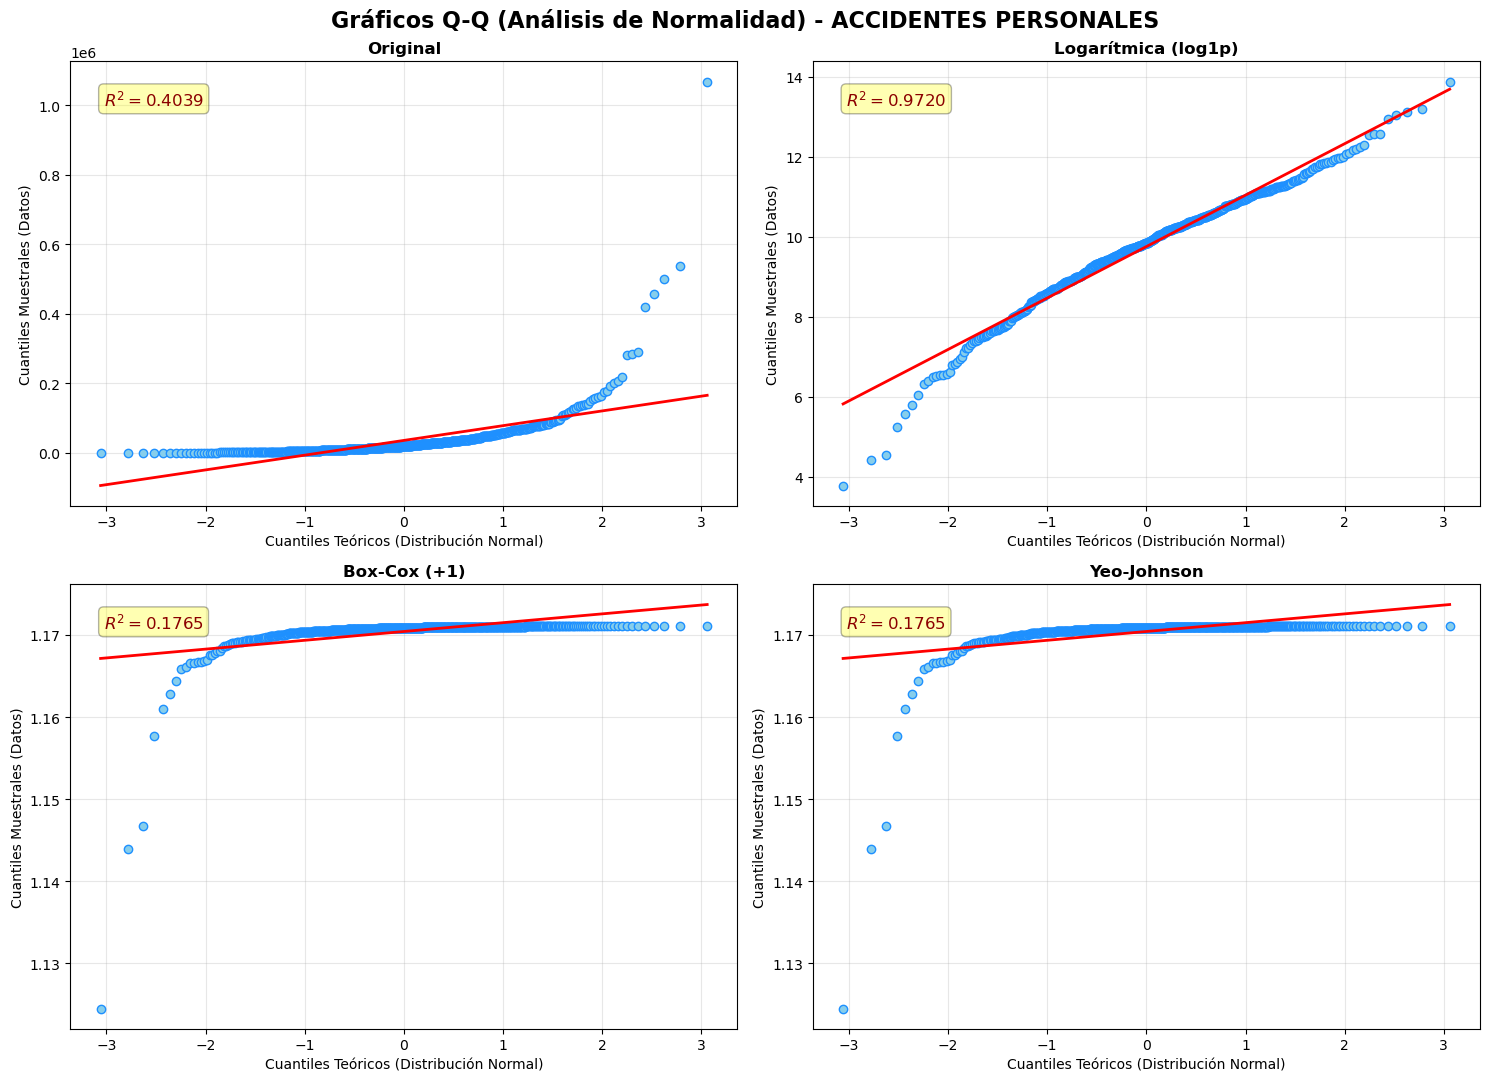

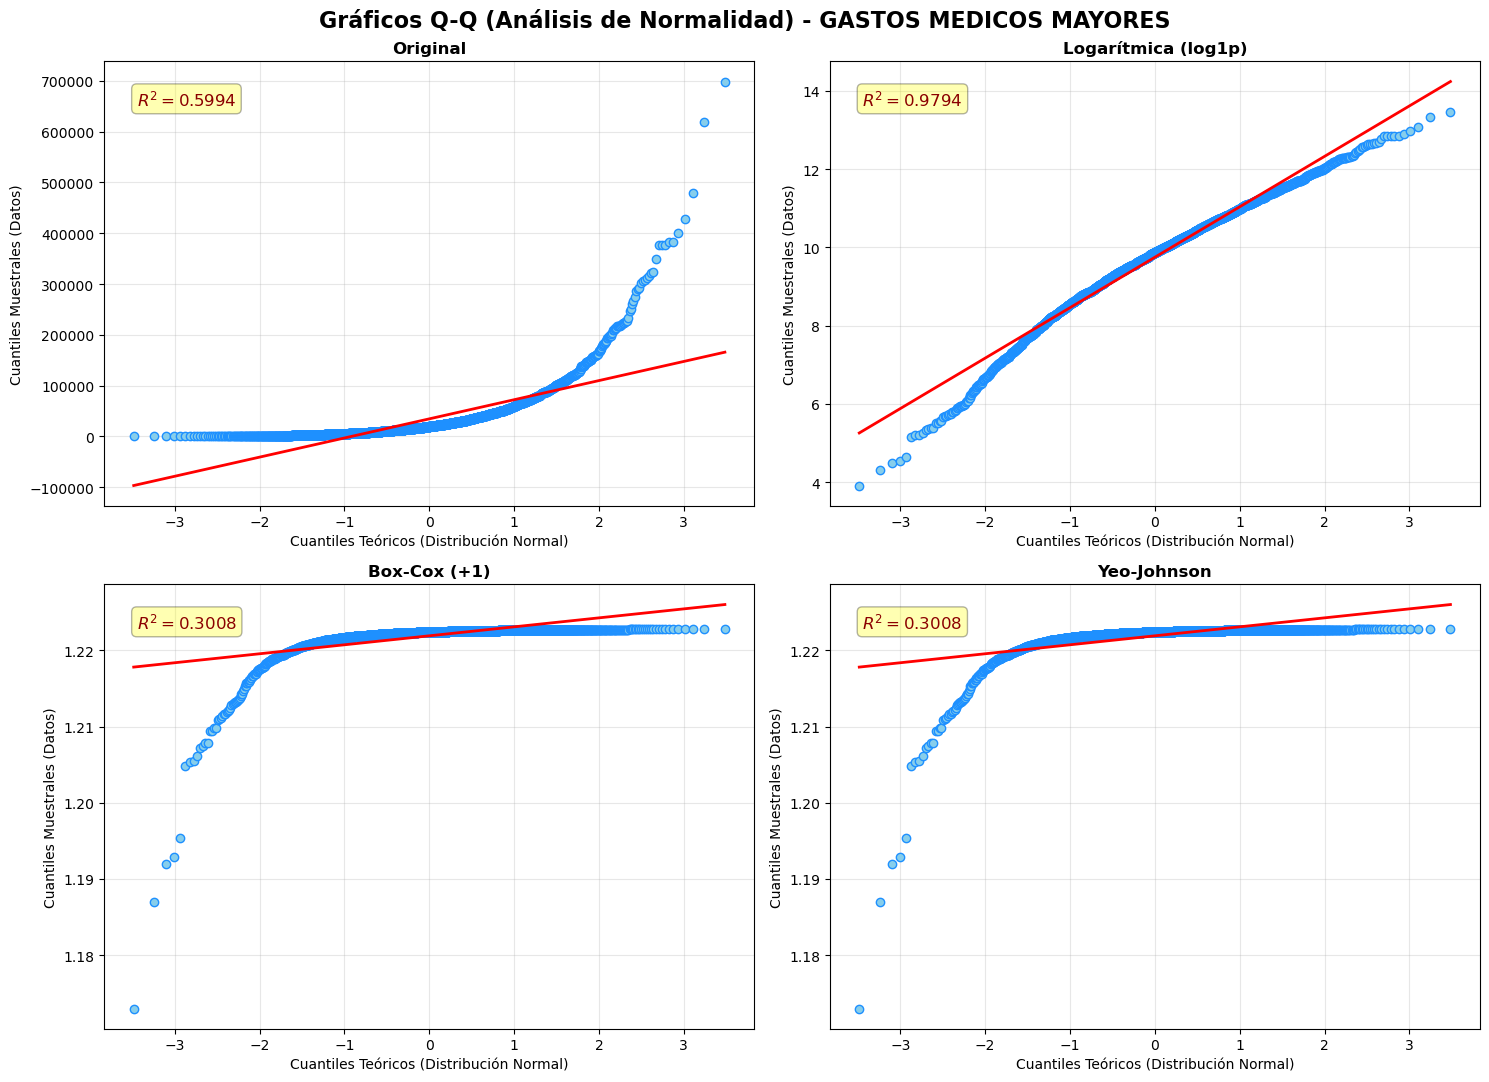


============ TEST DE NORMALIDAD ============

------------ Accidentes Personales

✅ La asimetría bajó de 20.52 a 2.43
TEST DE NORMALIDAD (Shapiro-Wilk) - N = 500
H0: Los datos siguen distribución normal
Si p-valor > 0.05 → No rechazamos normalidad
Original        | Estadístico: 0.3882 | p-valor: 0.000000 | ❌ No normal
Log(Y+1)        | Estadístico: 0.9653 | p-valor: 0.000000 | ❌ No normal
Box-Cox         | Estadístico: 0.1848 | p-valor: 0.000000 | ❌ No normal
Yeo-Johnson     | Estadístico: 0.1848 | p-valor: 0.000000 | ❌ No normal

------------ Gastos Medicos Mayores

✅ La asimetría bajó de 10.87 a 2.35
TEST DE NORMALIDAD (Shapiro-Wilk) - N = 500
H0: Los datos siguen distribución normal
Si p-valor > 0.05 → No rechazamos normalidad
Original        | Estadístico: 0.5578 | p-valor: 0.000000 | ❌ No normal
Log(Y+1)        | Estadístico: 0.9845 | p-valor: 0.000036 | ❌ No normal
Box-Cox         | Estadístico: 0.3834 | p-valor: 0.000000 | ❌ No normal
Yeo-Johnson     | Estadístico: 0.3834 | p-v

In [ ]:
from scipy import stats
from scipy.stats import shapiro

# ========================================
# ============ FUNCION Q-Q PLOTS =========
# ========================================
def graficar_qq_plots(monto_original, monto_log, monto_bc, monto_yj, titulo_ramo):
    fig, axes = plt.subplots(2, 2, figsize=(15, 11))
    fig.suptitle(
        f"Gráficos Q-Q (Análisis de Normalidad) - {titulo_ramo}",
        fontsize=16,
        fontweight="bold",
    )

    series = [monto_original, monto_log, monto_bc, monto_yj]
    titulos = ["Original", "Logarítmica (log1p)", "Box-Cox (+1)", "Yeo-Johnson"]

    axes = axes.flatten()

    for i in range(4):
        ax = axes[i]
        data = series[i]

        (osm, osr), (slope, intercept, r) = stats.probplot(
            data, dist="norm", plot=ax
        )

        r_cuadrado = r**2

        ax.text(
            0.05,
            0.90,
            f"$R^2 = {r_cuadrado:.4f}$",
            transform=ax.transAxes,
            fontsize=12,
            fontweight="bold",
            color="darkred",
            bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.3),
        )

        ax.get_lines()[0].set_markerfacecolor("skyblue")
        ax.get_lines()[0].set_markeredgecolor("dodgerblue")
        ax.get_lines()[1].set_color("red")
        ax.get_lines()[1].set_linewidth(2)

        # Ajustes de etiquetas
        ax.set_title(titulos[i], fontsize=12, fontweight="semibold")
        ax.set_xlabel("Cuantiles Teóricos (Distribución Normal)")
        ax.set_ylabel("Cuantiles Muestrales (Datos)")
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


# -------------------------------------------
# Ramo: Accidentes Personales
# -------------------------------------------
mascara_ac = ac['monto_pagado'] > 0

graficar_qq_plots(
    monto_original = ac.loc[mascara_ac, 'monto_pagado'].values,
    monto_log      = ac_log.loc[mascara_ac, 'log_siniestro'].values,
    monto_bc       = y_bc_ac[mascara_ac],
    monto_yj       = y_yj_ac[mascara_ac],
    titulo_ramo    = "ACCIDENTES PERSONALES"
)

# -------------------------------------------
# Ramo: Gastos Médicos Mayores
# -------------------------------------------
mascara_gm = gm['monto_pagado'] > 0

graficar_qq_plots(
    monto_original = gm.loc[mascara_gm, 'monto_pagado'].values,
    monto_log      = gm_log.loc[mascara_gm, 'log_siniestro'].values,
    monto_bc       = y_bc_gm[mascara_gm],
    monto_yj       = y_yj_gm[mascara_gm],
    titulo_ramo    = "GASTOS MEDICOS MAYORES"
)

# ============================================
# ============ TEST DE NORMALIDAD ============
# ============================================

# Creamos una función robusta basada en lo visto en clase
def normalidad(datos, col_original, col_log, y_boxcox, y_yj, semilla=42):
    # Filtramos las pólizas afectadas (siniestros > 0) para un análisis real
    mascara = datos[col_original] > 0

    # Convertimos los arrays de Box-Cox y Yeo-Johnson a Series usando el mismo índice de los datos
    serie_bc = pd.Series(y_boxcox, index=datos.index)
    serie_yj = pd.Series(y_yj, index=datos.index)

    # Creamos el diccionario tomando el .sample(500) únicamente de las filas con siniestro
    variables_test = {
        "Original": datos.loc[mascara, col_original].sample(500, random_state=semilla),
        "Log(Y+1)": datos.loc[mascara, col_log].sample(500, random_state=semilla),
        "Box-Cox": serie_bc.loc[mascara].sample(500, random_state=semilla),
        "Yeo-Johnson": serie_yj.loc[mascara].sample(500, random_state=semilla)
    }

    print("=" * 65)
    print("TEST DE NORMALIDAD (Shapiro-Wilk) - N = 500")
    print("H0: Los datos siguen distribución normal")
    print("Si p-valor > 0.05 → No rechazamos normalidad")
    print("=" * 65)

    for nombre, data in variables_test.items():
        stat, p_valor = shapiro(data)
        decision = "✅ Normal" if p_valor > 0.05 else "❌ No normal"
        print(
            f"{nombre:15s} | Estadístico: {stat:.4f} | p-valor: {p_valor:.6f} | {decision}"
        )


print("\n============================================")
print("============ TEST DE NORMALIDAD ============")
print("============================================")

print("\n------------ Accidentes Personales")

normalidad(t_log(ac), "monto_pagado", "log_siniestro", y_bc_ac, y_yj_ac)

print("\n------------ Gastos Medicos Mayores")

normalidad(t_log(gm), "monto_pagado", "log_siniestro", y_bc_gm, y_yj_gm)


# COMENTARIOS
# Para ambos ramos y para todas las transformaciones (logaritmica, box cox y Yeo Johnson)
# se rechaza la hipotesis nula, es decir, rechazamos normalidad debido a que el p-valuo
# resulto ser muy cercano a cero. Por lo tanto, los montos de siniestros no siguen una 
# distribucion normal.
# Sin embargo, aunque no se logró la normalidad, si se redujo la asimetría. En Accidentes 
# Personales disminuyó de 20.52 a 2.43. En Gastos Médicos disminuyó de 10.87 a 2.35.
# Podemos observar que la transformacion con logaritmo fue la que mas aproximo a la
# normalidad las cifras.
# Estos resultados pueden deberse a la alta concentración de datos en el cero y a aquellos
# montos muy grandes, de indole catastrofica.

7.	Calcula las siguientes variables derivadas: mayor de 65 años, Siniestros altos (se definen como los montos pagados mayores a $25,000 en accidentes personales y mayores a $200,000 en gastos médicos). ¿Cuántos siniestros cumplen estas características y qué % del total de siniestros representan?

In [8]:
# ==============================================
# ========== VARIABLE MAYOR A 65 AÑOS ==========
# ==============================================

ac["mayor_65"] = (ac["edad"] > 65).astype(int)
gm["mayor_65"] = (gm["edad"] > 65).astype(int)

# =============================================
# ========= VARIABLE SINIESTROS ALTOS =========
# =============================================

ac["siniestros_altos"] = (ac["monto_pagado"] > 25000).astype(int)
gm["siniestros_altos"] = (gm["monto_pagado"] > 200000).astype(int)

# Solo pólizas afectadas con monto > 0
ac_siniestrados = ac[ac["monto_pagado"] > 0]
gm_siniestrados = gm[gm["monto_pagado"] > 0]

# ====================================
# ============ RESULTADOS ============
# ====================================

print("============== RAMO: ACCIDENTES PERSONALES ==============")
print(f"Personas mayores a 65 años : {ac['mayor_65'].sum()} ({ (ac['mayor_65'].sum()/len(ac))*100 :.2f}%) del total de asegurados en el ramo"
)

print(f"Siniestros altos (> $25,000): {ac_siniestrados['siniestros_altos'].sum()} ({(ac_siniestrados['siniestros_altos'].sum()/len(ac_siniestrados))*100 :.2f}%) del total de siniestros"
)

print("\n============== RAMO: GASTOS MÉDICOS MAYORES ==============")
print(f"Personas mayores a 65 años  : {gm['mayor_65'].sum()} ({(gm['mayor_65'].sum()/len(gm))*100 :.2f}%) del total de asegurados en el ramo"
)

print(f"Siniestros altos (> $200,000): {gm_siniestrados['siniestros_altos'].sum()} ({(gm_siniestrados['siniestros_altos'].sum()/len(gm_siniestrados))*100 :.2f}%) del total de siniestros"
)
print("==========================================================")

============== RAMO: ACCIDENTES PERSONALES ==============
Personas mayores a 65 años : 37 (0.71%) del total de asegurados en el ramo
Siniestros altos (> $25,000): 263 (42.22%) del total de siniestros

============== RAMO: GASTOS MÉDICOS MAYORES ==============
Personas mayores a 65 años  : 161 (0.71%) del total de asegurados en el ramo
Siniestros altos (> $200,000): 45 (1.60%) del total de siniestros


8.	Calcula la media del siniestro por sexo, año de inicio de vigencia y plan.

In [9]:

print("\n============================================")
print("=========== ACCIDENTES PERSONALES ===========")
print("============================================")

medias_ac = (ac.groupby(["sexo", "anio_poliza", "plan"])["monto_pagado"]
    .mean()
    .reset_index()
)

# Renombramos la columna
medias_ac.rename(columns={"monto_pagado": "media_siniestro"}, inplace=True)
print (" \n=== MEDIA DE SINIESTROS POR SEXO, AÑO DE INICIO DE VIGENCIA Y PLAN ===\n")
print(medias_ac[~medias_ac['media_siniestro'].isna()].to_string())

# Agrupamos por cada variable y calculamos la media
medias_sexo_ac = (
    gm.groupby(["sexo"])["monto_pagado"]
    .mean()
    .reset_index()
)

print (" \n--- MEDIA DE SINIESTROS POR SEXO ---\n")
print(medias_sexo_ac[~medias_sexo_ac['monto_pagado'].isna()].to_string())

medias_anio_ac = (
    gm.groupby(["anio_poliza"])["monto_pagado"]
    .mean()
    .reset_index()
)
print (" \n--- MEDIA DE SINIESTROS POR AÑO DE INICIO DE VIGENCIA ===\n")
print(medias_anio_ac[~medias_anio_ac['monto_pagado'].isna()].to_string())

medias_plan_ac = (
    gm.groupby(["plan"])["monto_pagado"]
    .mean()
    .reset_index()
)

print (" \n--- MEDIA DE SINIESTROS POR PLAN ---\n")
print(medias_plan_ac[~medias_plan_ac['monto_pagado'].isna()].to_string())


print("\n============================================")
print("=========== GASTOS MEDICOS MAYORES ===========")
print("============================================\n")

# Agrupamos por las 3 variables y calculamos la media
medias_gm = (
    gm.groupby(["sexo", "anio_poliza", "plan"])["monto_pagado"]
    .mean()
    .reset_index()
)

# Renombramos la columna
medias_gm.rename(columns={"monto_pagado": "media_siniestro"}, inplace=True)

print (" --- MEDIA DE SINIESTROS POR SEXO, AÑO DE INICIO DE VIGENCIA Y PLAN ---\n")
print(medias_gm[~medias_gm['media_siniestro'].isna()].to_string())

# Agrupamos por cada variable y calculamos la media
medias_sexo_gm = (
    gm.groupby(["sexo"])["monto_pagado"]
    .mean()
    .reset_index()
)

print (" \n--- MEDIA DE SINIESTROS POR SEXO ---\n")
print(medias_sexo_gm[~medias_sexo_gm['monto_pagado'].isna()].to_string())

medias_anio_gm = (
    gm.groupby(["anio_poliza"])["monto_pagado"]
    .mean()
    .reset_index()
)
print (" \n--- MEDIA DE SINIESTROS POR AÑO DE INICIO DE VIGENCIA ===\n")
print(medias_anio_gm[~medias_anio_gm['monto_pagado'].isna()].to_string())

medias_plan_gm = (
    gm.groupby(["plan"])["monto_pagado"]
    .mean()
    .reset_index()
)

print ("\n--- MEDIA DE SINIESTROS POR PLAN ---\n")
print(medias_plan_gm[~medias_plan_gm['monto_pagado'].isna()].to_string())



=========== ACCIDENTES PERSONALES ===========
 
=== MEDIA DE SINIESTROS POR SEXO, AÑO DE INICIO DE VIGENCIA Y PLAN ===

    sexo  anio_poliza        plan  media_siniestro
6      F         2019    Familiar      2763.159856
7      F         2019  Individual      4692.569375
18     F         2020    Familiar      7705.865360
19     F         2020  Individual      3293.992769
30     F         2021    Familiar      5678.685305
31     F         2021  Individual      7491.114065
42     F         2022    Familiar      4417.030212
43     F         2022  Individual      6883.836633
54     F         2023    Familiar      3558.009617
55     F         2023  Individual      5160.714260
66     F         2024    Familiar      3317.672097
67     F         2024  Individual      3639.167932
78     M         2019    Familiar      2660.577115
79     M         2019  Individual      4182.472591
90     M         2020    Familiar      4678.254131
91     M         2020  Individual      4191.676387
102    M    